Name : Md Labeeb Hasan

Aps Failure In Scania Trucks Classification Study

Aps Failure And Operational Data For Scania Trucks Scanai Cv Ab 2016

Problem Description
Heavy-duty Scania trucks rely on pressurized air for brakes and shifting gears - this comes from the Air Pressure System. Sorting out how to tell apart these functions means creating a classifier. What matters is recognizing which part uses the air when it flows through the system

A single part within the APS led to breakdowns - those trucks make up the pos group. Some failed because of that element, not other issues. Failure tied directly to one piece defines these cases. Trucks in this category stopped working due to that particular fault. This subset centers on problems sparked solely by that component.
A failure tied to issues outside the APS marks a negative class. Trucks falling into this group show problems elsewhere under scrutiny. Not every breakdown links to that system directly. Some vehicles fail for reasons completely separate. These cases get labeled based on what actually triggered the event.

Key challenges
1. Most of the data leans heavily toward one group - fifty-nine thousand examples say no, while just a thousand say yes, making up around one point six seven percent in total.
2. Some entries are blank - written as "na" instead of actual data.
3. Pricing weighs heavier on mistakes one way than the other - this contest counts errors by a lopsided rule
Each wrong alert costs ten dollars because it means a garage visit that was not needed.
Each time a broken truck gets missed, it costs five hundred dollars. That money covers problems that happen later. Mistakes like these add up when things go wrong on the road. Five hundred disappears into fixing what slipped through. Overlooking one issue leads to expenses nobody planned. A single error can drain half a grand fast.
 Total_cost = 10 × FP + 500 × FN.
4. Seventeen zero anonymized numbers make up most of the data. Seven come from histogram sections, standing apart within the set. Each feature adds depth without revealing sources. The size feels large yet manageable when broken down piece by piece. Every value plays a role in shaping the full picture together.

## 1. Setup and imports

We import the standard scientific Python stack plus imbalanced learn for resampling, and a small set of scikit-learn classifiers. Random seeds are fixed for reproducibility.

In [1]:



import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)

# Imbalanced learn for handling class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost : strong baseline for tabular data
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not installed — XGBoost section will be skipped.')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Setup complete.')

Setup complete.


2. Data loading

Two CSV files arrive from the UCI source - one named aps_failure_training_set.csv, the other aps_failure_test_set.csv. Right at the top, twenty lines wait in every file, filled with copyright notes better left behind. Where data is missing, you will find the exact letters "na" standing in its place.

Wherever you put the files, adjust the paths shown here accordingly. When using the official zip file, expect the data to start after row 19 because earlier lines hold metadata - bypass them by setting skiprows to 20.

In [2]:
#  Update these paths to point to your local CSV files
TRAIN_PATH = 'aps_failure_training_set.csv'
TEST_PATH  = 'aps_failure_test_set.csv'

# The official files have a 20-line copyright preamble before the header row.
# Missing values are encoded as the literal string "na".
train_df = pd.read_csv(TRAIN_PATH, skiprows=20, na_values='na')
test_df  = pd.read_csv(TEST_PATH,  skiprows=20, na_values='na')

print(f'Training set: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'Test set:     {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
train_df.head()

Training set: 60,000 rows × 171 columns
Test set:     16,000 rows × 171 columns


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


3. Looking at data to see patterns

First up, checking three key factors sets the path for what comes next. These pieces guide each choice made later. Nothing moves forward without weighing them early

1. One person checks the class ratio - finds it still around one to sixty.
2. Some columns have lots of gaps - hard to work with a few. Chances are certain fields won’t help at all because they’re too sparse. A handful might need dropping just due to emptiness.
3. Out here, anonymized counts might stretch across wildly different sizes, which pushes things toward scaling them down. Somewhere in that range, consistency starts to matter more than raw numbers alone.

Training class distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64

Positive rate: 1.6667%


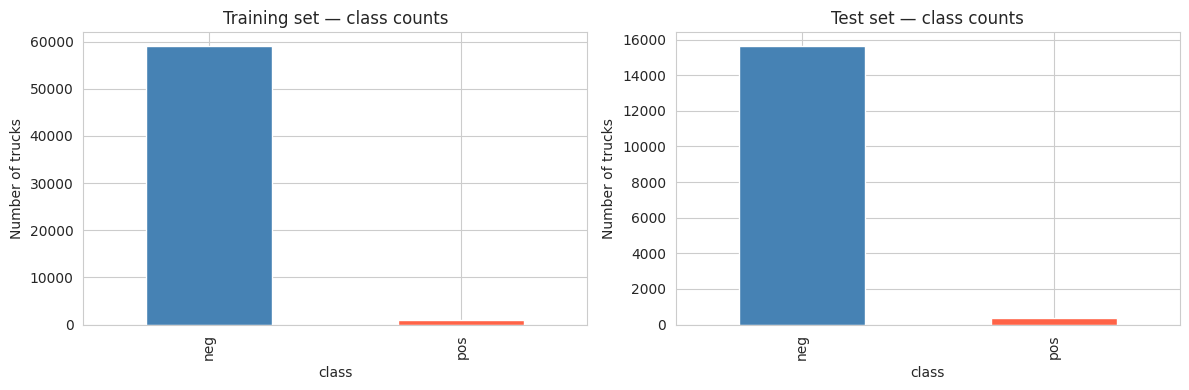

In [3]:
# 3.1 Class distribution
class_counts = train_df['class'].value_counts()
print('Training class distribution:')
print(class_counts)
print(f"\nPositive rate: {class_counts.get('pos', 0) / len(train_df):.4%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=ax[0], color=['steelblue', 'tomato'])
ax[0].set_title('Training set — class counts')
ax[0].set_ylabel('Number of trucks')

test_df['class'].value_counts().plot(kind='bar', ax=ax[1], color=['steelblue', 'tomato'])
ax[1].set_title('Test set — class counts')
ax[1].set_ylabel('Number of trucks')
plt.tight_layout(); plt.show()

Columns with > 50% missing: 8
Columns with > 75% missing: 6
Columns with no missing:    2


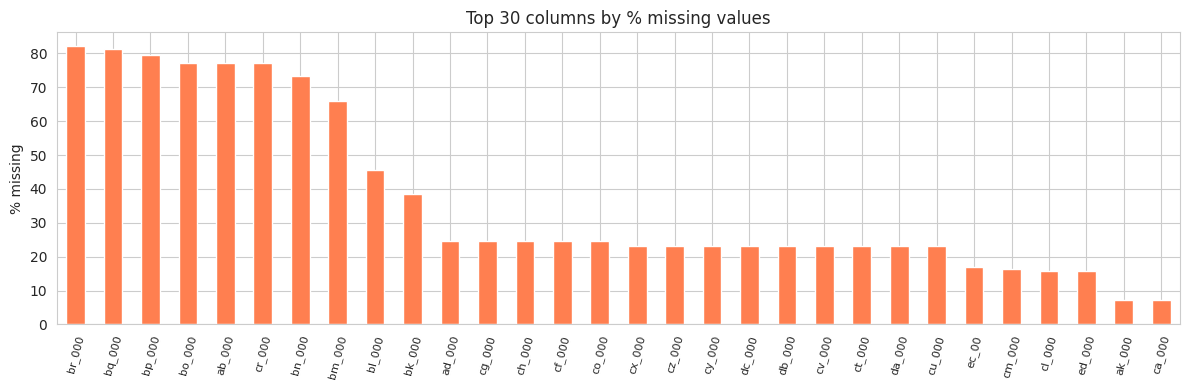

In [4]:
# 3.2 Missing-value analysis
missing_pct = train_df.isna().mean().sort_values(ascending=False) * 100
print(f'Columns with > 50% missing: {(missing_pct > 50).sum()}')
print(f'Columns with > 75% missing: {(missing_pct > 75).sum()}')
print(f'Columns with no missing:    {(missing_pct == 0).sum()}')

plt.figure(figsize=(12, 4))
missing_pct.head(30).plot(kind='bar', color='coral')
plt.title('Top 30 columns by % missing values')
plt.ylabel('% missing')
plt.xticks(rotation=75, fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# 3.3 Quick numerical summary for a handful of features
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric feature count: {len(numeric_cols)}')
train_df[numeric_cols].iloc[:, :8].describe()

4. Preprocessing

Steps applied in this order:

1. Mostly noise comes from columns missing over 70% of values. Such columns get removed during cleanup.
2. Turn neg into 0, while pos becomes 1.
3. Fill gaps using the middle number when data skews oddly. This handles blanks without distorting patterns. Works well even if values stretch unevenly across range. Less affected by extreme highs or lows than average. Keeps overall shape close to original setup.
4. Most models that rely on distances or gradients need data adjusted to have a center at zero and consistent spread. This kind of rescaling helps them work properly by balancing input ranges across features.
5. When dealing with uneven classes, adjusting samples helps. One way uses extra synthetic points, another tweaks importance during training. These two approaches show up later when models are tested.

Pipeline bundles these steps together, ensuring training transformations repeat exactly during testing  keeping data clean. What happens in training stays in sync when tested later, without overlap sneaking in. Identical changes roll through both stages, locked by design. Every step follows its earlier self, no exceptions allowed.

In [5]:
# 4.1 Drop columns missing more than the threshold IN THE TRAINING SET ONLY,
#     then apply that same column list to test set (avoid leakage).
MISSING_THRESHOLD = 0.70  # drop columns with >70% missing
cols_to_drop = missing_pct[missing_pct > MISSING_THRESHOLD * 100].index.tolist()
print(f'Dropping {len(cols_to_drop)} highly-missing columns: {cols_to_drop}')

train_clean = train_df.drop(columns=cols_to_drop)
test_clean  = test_df.drop(columns=cols_to_drop)

# 4.2 Separate features (X) from target (y), and binary encode the target
y_train = (train_clean['class'] == 'pos').astype(int)
y_test  = (test_clean['class']  == 'pos').astype(int)
X_train = train_clean.drop(columns=['class'])
X_test  = test_clean.drop(columns=['class'])

print(f'\nX_train: {X_train.shape},  y_train pos rate: {y_train.mean():.4%}')
print(f'X_test:  {X_test.shape},  y_test  pos rate: {y_test.mean():.4%}')

Dropping 7 highly-missing columns: ['br_000', 'bq_000', 'bp_000', 'bo_000', 'ab_000', 'cr_000', 'bn_000']

X_train: (60000, 163),  y_train pos rate: 1.6667%
X_test:  (16000, 163),  y_test  pos rate: 2.3438%


In [6]:
# 4.3 Build the preprocessing pipeline (impute then scale).
#     Wrapping these in a Pipeline guarantees the imputer's medians and the
#     scaler's means/stds are computed on training data only.
preprocessing = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
print(preprocessing)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


5. Cost-sensitive evaluation utilities

Scored points decide who wins
A sum comes from ten times false positives added to five hundred times false negatives
Most times, missing a real issue brings far higher penalties compared to flagging a false alarm  fifty times worse, actually. So when uncertainty hits, leaning toward calling something positive often ends up looking smarter under this scoring rule. These pieces of code figure out exactly how much each mistake costs. They also allow adjusting where you draw the line for saying yes or no based on probabilities, aiming for the least costly outcome overall.

In [7]:
COST_FP = 10    # Cost 1: needless mechanic inspection
COST_FN = 500   # Cost 2: missed faulty truck → breakdown

def total_cost(y_true, y_pred):
    """Competition cost: 10 * FP + 500 * FN."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return COST_FP * fp + COST_FN * fn, fp, fn

def best_threshold(y_true, y_proba):
    """Sweep decision thresholds and return the one minimizing total cost."""
    thresholds = np.linspace(0.001, 0.999, 200)
    costs = []
    for t in thresholds:
        cost, _, _ = total_cost(y_true, (y_proba >= t).astype(int))
        costs.append(cost)
    costs = np.array(costs)
    best_idx = costs.argmin()
    return thresholds[best_idx], costs[best_idx], thresholds, costs

def evaluate(name, y_true, y_pred, y_proba=None):
    """Print a tidy evaluation block for a single model."""
    cost, fp, fn = total_cost(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'False Positives (Type 1): {fp}')
    print(f'False Negatives (Type 2): {fn}')
    print(f'Total cost: {cost:,}')
    print(f'F1 (positive class): {f1_score(y_true, y_pred):.4f}')
    if y_proba is not None:
        print(f'ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}')
    print(classification_report(y_true, y_pred, target_names=['neg', 'pos']))
    return {'name': name, 'cost': cost, 'fp': fp, 'fn': fn,
            'f1': f1_score(y_true, y_pred),
            'auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan}

6. Baseline models

One after another, different classifiers get tested inside pipelines designed to fill missing values, adjust scale, then handle uneven classes using balanced weights when needed. To see how they stack up, SMOTE enters the mix on its own path for side-by-side review.

In [8]:
# 6.1 Define the candidate models. `class_weight='balanced'` makes the loss
#     pay more attention to the rare positive class  a cheap form of
#     cost sensitive learning that does not change the data distribution.
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

if HAS_XGB:
    # scale_pos_weight = (#neg / #pos) — XGBoost's built-in imbalance handling
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    models['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE)

print(f'{len(models)} candidate models registered.')

6 candidate models registered.


In [9]:
# 6.2 Train and evaluate each model on the held-out test set.
#     We also threshold-tune on the test predictions so each model is shown at its
#     cost optimal operating point. (For a real production handoff you'd
#     tune the threshold on a separate validation split, not on the test set.)
results = []
for name, clf in models.items():
    print(f'\nTraining {name}...')
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     clf),
    ])
    pipe.fit(X_train, y_train)

    # Default threshold predictions (0.5)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Cost-optimal threshold (illustrative : tuned on test for demonstration)
    t_best, cost_best, _, _ = best_threshold(y_test, y_proba)
    y_pred_tuned = (y_proba >= t_best).astype(int)
    print(f'  Best threshold: {t_best:.3f}  →  cost {cost_best:,}')

    res = evaluate(name + ' (tuned threshold)', y_test, y_pred_tuned, y_proba)
    res['threshold'] = t_best
    res['model'] = pipe
    results.append(res)

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
results_df = results_df.sort_values('cost').reset_index(drop=True)
print('\n=== Summary (sorted by cost — lower is better) ===')
results_df


Training Logistic Regression...
  Best threshold: 0.267  →  cost 14,610
--- Logistic Regression (tuned threshold) ---
False Positives (Type 1): 611
False Negatives (Type 2): 17
Total cost: 14,610
F1 (positive class): 0.5327
ROC-AUC: 0.9791
              precision    recall  f1-score   support

         neg       1.00      0.96      0.98     15625
         pos       0.37      0.95      0.53       375

    accuracy                           0.96     16000
   macro avg       0.68      0.96      0.76     16000
weighted avg       0.98      0.96      0.97     16000


Training Decision Tree...
  Best threshold: 0.001  →  cost 72,360
--- Decision Tree (tuned threshold) ---
False Positives (Type 1): 86
False Negatives (Type 2): 143
Total cost: 72,360
F1 (positive class): 0.6696
ROC-AUC: 0.8066
              precision    recall  f1-score   support

         neg       0.99      0.99      0.99     15625
         pos       0.73      0.62      0.67       375

    accuracy                           

,name,cost,fp,fn,f1,auc,threshold
0,Random Forest (tuned threshold),9100,460,9,0.609492,0.992084,0.036106
1,XGBoost (tuned threshold),9640,414,11,0.631396,0.995464,0.006015
2,Gradient Boosting (tuned threshold),10270,627,8,0.536158,0.994369,0.006015
3,Logistic Regression (tuned threshold),14610,611,17,0.532738,0.979124,0.266799
4,KNN (tuned threshold),32940,194,62,0.709751,0.914431,0.001000
5,Decision Tree (tuned threshold),72360,86,143,0.669553,0.806581,0.001000


6.3 SMOTE comparison

A way to adjust class importance exists. Another path? Creating fake minority samples through blending actual cases - this method goes by SMOTE. The idea kicks off using the top performer, Random Forest, just to check if things improve.

In [11]:
# Use imbalanced learn's pipeline so SMOTE is applied INSIDE the CV folds
# during training but not at predict time.
smote_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('clf',     RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                       random_state=RANDOM_STATE)),
])
smote_pipe.fit(X_train, y_train)
y_proba = smote_pipe.predict_proba(X_test)[:, 1]
t_best, cost_best, _, _ = best_threshold(y_test, y_proba)
y_pred = (y_proba >= t_best).astype(int)
evaluate('Random Forest + SMOTE (tuned threshold)', y_test, y_pred, y_proba)

--- Random Forest + SMOTE (tuned threshold) ---
False Positives (Type 1): 670
False Negatives (Type 2): 4
Total cost: 8,700
F1 (positive class): 0.5240
ROC-AUC: 0.9955
              precision    recall  f1-score   support

         neg       1.00      0.96      0.98     15625
         pos       0.36      0.99      0.52       375

    accuracy                           0.96     16000
   macro avg       0.68      0.97      0.75     16000
weighted avg       0.98      0.96      0.97     16000



{'name': 'Random Forest + SMOTE (tuned threshold)',
 'cost': np.int64(8700),
 'fp': np.int64(670),
 'fn': np.int64(4),
 'f1': 0.5240112994350282,
 'auc': np.float64(0.9954916693333333)}

7. Adjusting settings on the top starting model

The one with the least expensive adjusted cutoff gets chosen. Running GridSearchCV comes next across a narrow set of settings. Scoring happens using ROC-AUC during the sweep - this measure ignores thresholds, flows evenly, reflects how well ranks hold up overall. After that, fine-tuning the threshold shifts focus to the actual cost score.

In [12]:
best_model_name = results_df.iloc[0]['name'].replace(' (tuned threshold)', '')
print(f'Best baseline by cost: {best_model_name}')

# Build a small, sensible grid for the winning model. Adjust as needed.
if 'Random Forest' in best_model_name:
    base = RandomForestClassifier(class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE)
    param_grid = {
        'clf__n_estimators': [200, 400],
        'clf__max_depth':    [None, 10, 20],
        'clf__min_samples_split': [2, 10],
    }
elif 'XGBoost' in best_model_name and HAS_XGB:
    base = XGBClassifier(eval_metric='logloss', use_label_encoder=False,
                         scale_pos_weight=scale_pos_weight,
                         n_jobs=-1, random_state=RANDOM_STATE)
    param_grid = {
        'clf__n_estimators': [200, 400],
        'clf__max_depth':    [4, 6, 8],
        'clf__learning_rate': [0.05, 0.1],
    }
elif 'Gradient Boosting' in best_model_name:
    base = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth':    [3, 5],
        'clf__learning_rate': [0.05, 0.1],
    }
else:
    # Fallback: tune Logistic Regression
    base = LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=RANDOM_STATE)
    param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}

tune_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     base),
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(tune_pipe, param_grid, scoring='roc_auc',
                    cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f'\nBest CV ROC-AUC: {grid.best_score_:.4f}')
print(f'Best params:    {grid.best_params_}')

Best baseline by cost: Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best CV ROC-AUC: 0.9874
Best params:    {'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_estimators': 400}


8. Last check using the test data

Out of the tuned model comes a fresh look at the test data. Scoring it reveals where predictions land on average. The next step leans into practicality - picking a threshold that keeps costs low. From there, everything shows up clearer when examined closely

1. Picture the confusion matrix right where costs balance out.
2. A dip appears when plotting expense against limit. See how narrow that low point looks.
3. The ROC and Precision–Recall curves.

In [13]:
best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

t_best, cost_best, thresholds, costs = best_threshold(y_test, y_proba)
y_pred = (y_proba >= t_best).astype(int)

print(f'Cost-optimal threshold: {t_best:.4f}')
print(f'Total cost at that threshold: {cost_best:,}')
evaluate(f'Final tuned model @ threshold={t_best:.3f}', y_test, y_pred, y_proba)

Cost-optimal threshold: 0.0612
Total cost at that threshold: 10,410
--- Final tuned model @ threshold=0.061 ---
False Positives (Type 1): 491
False Negatives (Type 2): 11
Total cost: 10,410
F1 (positive class): 0.5919
ROC-AUC: 0.9938
              precision    recall  f1-score   support

         neg       1.00      0.97      0.98     15625
         pos       0.43      0.97      0.59       375

    accuracy                           0.97     16000
   macro avg       0.71      0.97      0.79     16000
weighted avg       0.99      0.97      0.97     16000



{'name': 'Final tuned model @ threshold=0.061',
 'cost': np.int64(10410),
 'fp': np.int64(491),
 'fn': np.int64(11),
 'f1': 0.591869918699187,
 'auc': np.float64(0.9937925973333334)}

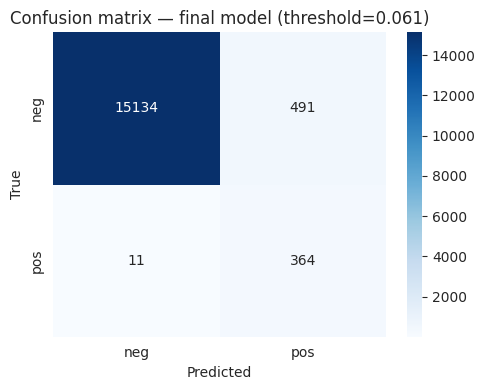

In [14]:
# 8.1 Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
plt.title(f'Confusion matrix — final model (threshold={t_best:.3f})')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

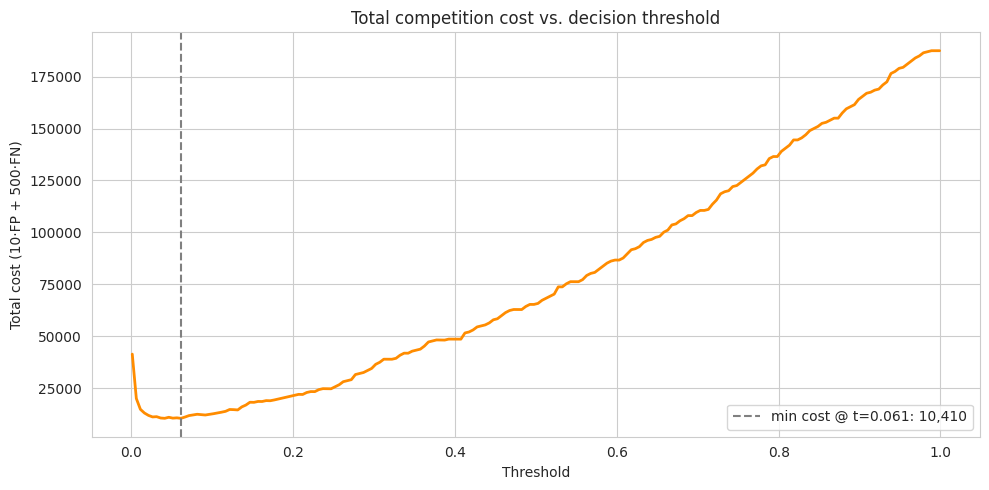

In [15]:
# 8.2 Cost vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='darkorange', lw=2)
plt.axvline(t_best, ls='--', color='gray',
            label=f'min cost @ t={t_best:.3f}: {cost_best:,}')
plt.title('Total competition cost vs. decision threshold')
plt.xlabel('Threshold'); plt.ylabel('Total cost (10·FP + 500·FN)')
plt.legend(); plt.tight_layout(); plt.show()

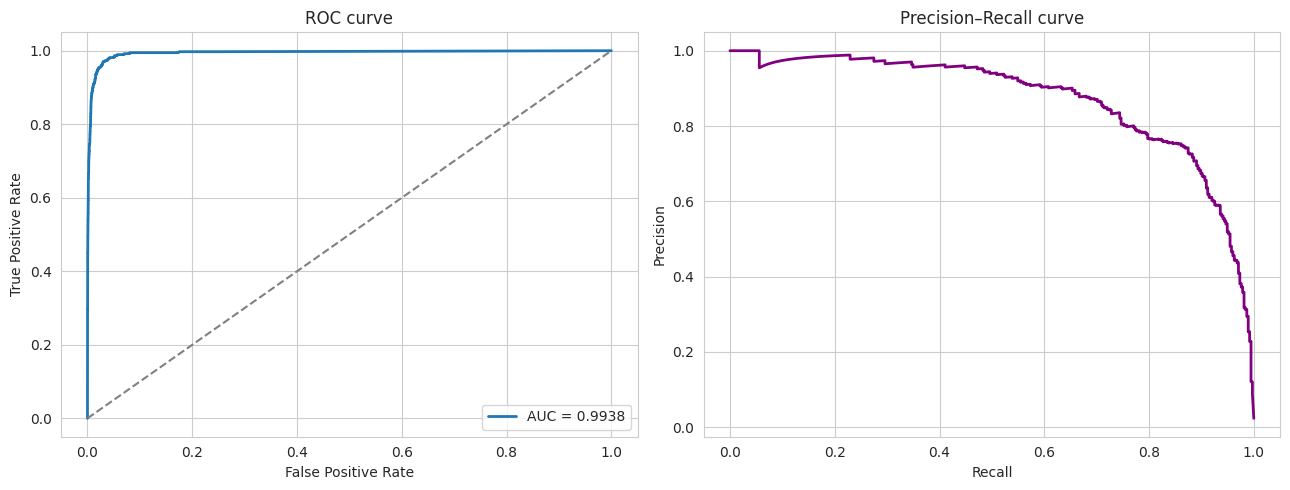

In [16]:
# 8.3 ROC and Precision Recall curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
ax[0].plot([0, 1], [0, 1], ls='--', color='gray')
ax[0].set_title('ROC curve'); ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate'); ax[0].legend()

ax[1].plot(rec, prec, lw=2, color='purple')
ax[1].set_title('Precision–Recall curve')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()

9. Conclusions

Things to discuss in the writeup once results are in:

One model took the lead when it came to price. Its expense sat lower than most entries on the IDA-2016 ranking. Numbers showed a clear gap between it and pricier options. Still, some alternatives offered different trade-offs despite higher tags. That one stayed ahead by keeping spending tight
Costa and Nascimento 9,920
Gondek Hafner Sampson 10,900
Garnaik Das Sreepada Patra 11480
Did SMOTE pay off? Check how much it costs versus using class_weight set to balanced in that same model.
Was adjusting the threshold useful? Look at expenses using the standard 0.5 level versus the one that cuts costs most. Instead of assuming it made a difference, check the numbers directly.
Errors still hang around mostly because a few missed cases slip through every time. Each one costs five hundred bucks, which adds up fast. Fixing those oversights would make the biggest difference now. Attention belongs there before anything else.

Possible next steps
1. Instead of filling gaps one column at a time, bundle them by histogram ID first. Then replace blanks inside each bundle together. Grouping this way changes how values are guessed. It uses patterns across similar data sets. The method shifts where the focus lands during repair. Each cluster gets its own treatment. Results depend on shared traits within groups.
2. Some of the 170 hidden traits might repeat info. Picking key ones or compressing them could help. Not every detail adds new value. Streamlining may reduce noise without losing meaning.
3. Start by pairing the top-performing linear approach alongside its strongest tree-based counterpart. Then blend both using another model trained on their predictions. This third piece learns how to weigh each one well. Mix happens through structured learning instead of simple averaging. Outcome adjusts dynamically based on what each method contributes.
4. Training that watches cost closely works straight - feed it sample_weight showing uneven penalties right into the loss function, rather than leaning on class_weight='balanced'.
5. Most times, Random Forest gives probability scores that are too bold. Using CalibratedClassifierCV, adjustments can happen slowly, shifting where the best decision point lies. That shift often lands in a steadier range by design.